# Limpeza e preparação da base

**Etapa:** auditoria de qualidade

A base é auditada sem editar o CSV oficial. Verificamos ausentes, duplicidades, lacunas temporais e movimentos extremos.

**Entrada:** arquivo bruto de ouro e base modelável  
**Resultado principal:** decisão de manter lacunas e extremos sem imputação do preço


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Qualidade dos dados e valores extremos

In [3]:
CLEANING_DECISION = (
    "Manter as lacunas do calendário e todos os valores extremos observados, "
    "sem imputação, remoção ou winsorização. Os extremos representam movimentos "
    "reais de mercado e serão acompanhados na análise de resíduos."
)

df = load_data()
protocol = load_protocol()
raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
raw_gold = pd.read_csv(
    raw_path,
    sep=None,
    engine="python",
    parse_dates=["DATE"],
    na_values=[".", ""],
)

gaps = df["DATE"].diff().dt.days.dropna()
returns = df["GOLD_PRICE"].pct_change()
return_median = returns.median()
return_mad = (returns - return_median).abs().median()
modified_z = 0.6745 * (returns - return_median) / return_mad

q1, q3 = df["GOLD_PRICE"].quantile([0.25, 0.75])
iqr = q3 - q1
level_outlier = (df["GOLD_PRICE"] < q1 - 1.5 * iqr) | (df["GOLD_PRICE"] > q3 + 1.5 * iqr)
return_outlier = modified_z.abs() > 3.5



,verificação,valor
0,linhas no arquivo bruto,12009
1,preços ausentes no arquivo bruto,368
2,linhas na base modelada,9864
3,nulos na base modelada,0
4,datas duplicadas,0
5,maior intervalo entre observações (dias),20
6,intervalos maiores que 3 dias,401
7,extremos pelo IQR no nível do preço,1416
8,retornos extremos pelo MAD,480


,DATE,GOLD_PRICE,return,modified_z
2548,1980-01-09,599.25,0.261845,33.329619
3097,1982-09-07,488.50,0.170060,21.646546
1110,1973-06-05,127.00,0.157175,20.006508
2557,1980-01-24,712.00,-0.155397,-19.780190
1244,1974-01-09,123.75,0.134801,17.158464
2555,1980-01-18,825.50,0.133539,16.997923
2592,1980-03-14,502.75,-0.124586,-15.858334
2553,1980-01-16,765.00,0.121701,15.491036
3002,1982-03-15,314.25,-0.119994,-15.273821
2560,1980-01-30,703.50,0.118442,15.076216


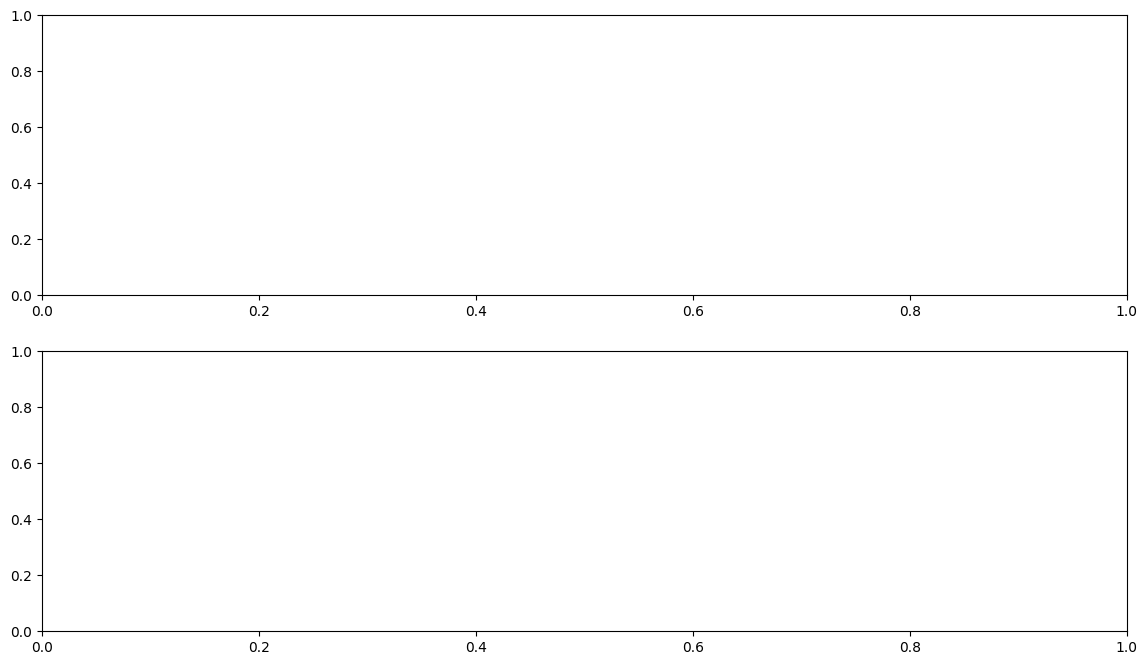

In [4]:
audit = pd.DataFrame(
    {
        "verificação": [
            "linhas no arquivo bruto",
            "preços ausentes no arquivo bruto",
            "linhas na base modelada",
            "nulos na base modelada",
            "datas duplicadas",
            "maior intervalo entre observações (dias)",
            "intervalos maiores que 3 dias",
            "extremos pelo IQR no nível do preço",
            "retornos extremos pelo MAD",
        ],
        "valor": [
            len(raw_gold),
            int(raw_gold["VALUE"].isna().sum()),
            len(df),
            int(df.isna().sum().sum()),
            int(df["DATE"].duplicated().sum()),
            int(gaps.max()),
            int((gaps > 3).sum()),
            int(level_outlier.sum()),
            int(return_outlier.sum()),
        ],
    }
)

outlier_candidates = df.loc[
    return_outlier,
    ["DATE", "GOLD_PRICE"],
].copy()
outlier_candidates["return"] = returns.loc[return_outlier]
outlier_candidates["modified_z"] = modified_z.loc[return_outlier]
outlier_candidates = outlier_candidates.sort_values("modified_z", key=abs, ascending=False)

display(audit)
display(outlier_candidates.head(20))

audit.to_csv(OUT / "data_quality_audit.csv", index=False)
outlier_candidates.to_csv(OUT / "outlier_candidates.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))


In [5]:
axes[0].plot(df["DATE"], df["GOLD_PRICE"], linewidth=1)
axes[0].scatter(
    df.loc[return_outlier, "DATE"],
    df.loc[return_outlier, "GOLD_PRICE"],
    color="crimson",
    s=18,
    label="retorno extremo pelo MAD",
)
axes[0].set_title("Preço do ouro e retornos sinalizados")
axes[0].legend()
axes[1].hist(returns.dropna(), bins=80, color="steelblue", edgecolor="white")
axes[1].set_title("Distribuição dos retornos simples")
axes[1].set_xlabel("retorno")
plt.tight_layout()
plt.savefig(OUT / "01_data_quality_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

if not CLEANING_DECISION:
    raise RuntimeError(
        "DECISÃO NECESSÁRIA: registre a decisão sobre lacunas e valores extremos."
    )

protocol["decisions"]["cleaning"] = CLEANING_DECISION
save_protocol(protocol)
print("Decisão registrada. O CSV oficial não foi alterado.")

Decisão registrada. O CSV oficial não foi alterado.


## Interpretação

Os 368 preços ausentes não foram interpolados. Os movimentos extremos foram preservados porque são compatíveis com mudanças reais de mercado e não há evidência concreta de erro.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/data_quality_audit.csv`
- `outputs/outlier_candidates.csv`
- `outputs/01_data_quality_outliers.png`